# Whakaari Dataset

This notebook builds the Whakaari case-study dataset for Cause–Trigger analysis. It combines waveform-derived hydrothermal/seismic features with weather, gas, and deformation variables on a common hourly grid.

In [ ]:
import sys
from pathlib import Path

import pandas as pd
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src/whakaari"
sys.path.append(str(SRC_DIR))

from whakaari_config import (
    WHAKAARI_START,
    WHAKAARI_END,
    WHAKAARI_ERUPTION_TIME,
    TILDE_SUMMARY_URL,
    TILDE_DATA_URL,
    WHAKAARI_LAT,
    WHAKAARI_LON,
    WHAKAARI_WAVEFORM_CONFIG,
    WHAKAARI_EQ_RADIUS_KM,
    WHAKAARI_EQ_MIN_MAGNITUDE,
)

from whakaari_geonet import (
    load_so2_flux,
    load_gnss_deformation,
    load_weather_vars,
    load_local_earthquake_counts,
)

from whakaari_waveform import build_waveform_dataset

from whakaari_dataset import (
    build_master_dataframe,
    prepare_analysis_dataframe,
    scale_analysis_dataframe,
    save_whakaari_datasets,
)

from whakaari_plotting_utils import (
    WHAKAARI_ALL_COLS,
    dataset_health_report,
    plot_with_eruption_time,
    plot_variable_pdfs,
    distribution_summary,
)

from whakaari_geo_metadata import whakaari_observable_metadata
from geo_utils import add_fdsn_station_coordinates
from whakaari_geo_plotting import plot_whakaari_observable_locations

client = Client("GEONET")

## 1. GeoNet and external data + local earthquake counts

We retrieve SO₂ flux and GNSS deformation from GeoNet/Tilde, and hourly weather variables from Open-Meteo. Antecedent Precipitation Index (API) and pressure drop are derived as hydrothermal forcing proxies.

In [2]:
so2 = load_so2_flux(TILDE_DATA_URL, WHAKAARI_START, WHAKAARI_END)
gnss = load_gnss_deformation(TILDE_DATA_URL, WHAKAARI_START, WHAKAARI_END)
weather_vars = load_weather_vars(
    WHAKAARI_LAT,
    WHAKAARI_LON,
    WHAKAARI_START,
    WHAKAARI_END,
)

In [3]:
local_eq, local_eq_events = load_local_earthquake_counts(
    client=client,
    start=WHAKAARI_START,
    end=WHAKAARI_END,
    latitude=WHAKAARI_LAT,
    longitude=WHAKAARI_LON,
    radius_km=WHAKAARI_EQ_RADIUS_KM,
    min_magnitude=WHAKAARI_EQ_MIN_MAGNITUDE,
    master_freq="1h",
)

print(local_eq.shape)
display(local_eq.head())
display(local_eq.describe())

print("Event catalogue rows:", len(local_eq_events))
display(local_eq_events.head())

(1704, 1)


,local_eq_count_1h
timestamp,
2019-10-01 00:00:00+00:00,0.0
2019-10-01 01:00:00+00:00,0.0
2019-10-01 02:00:00+00:00,0.0
2019-10-01 03:00:00+00:00,0.0
2019-10-01 04:00:00+00:00,0.0


,local_eq_count_1h
count,1704.00000
mean,0.02230
std,0.15545
min,0.00000
25%,0.00000
50%,0.00000
75%,0.00000
max,2.00000


Event catalogue rows: 38


,timestamp,latitude,longitude,depth_km,magnitude
0,2019-10-03 08:31:16.157187+00:00,-37.492023,177.349884,91.318359,1.952178
1,2019-10-03 21:59:14.988377+00:00,-37.507122,177.160019,113.641197,2.438961
2,2019-10-04 15:32:48.040216+00:00,-37.538536,177.218445,4.208585,2.064422
3,2019-10-06 00:47:35.187462+00:00,-37.349205,177.316757,5.000000,2.284503
4,2019-10-06 09:21:59.040931+00:00,-37.413063,176.964996,118.466621,2.211119


## 2. Waveform feature extraction

Waveform data from WSRZ are processed into hourly seismic features: hydrothermal tremor RMS, spectral ratio, HF event rate, and a continuous tremor-response energy variable.

In [ ]:
WHAKAARI_WAVEFORM_PKL = "../data/whakaari/whakaari_waveform.pkl"

waveform_df, waveform_failures = build_waveform_dataset(
    client=client,
    start=WHAKAARI_START,
    end=WHAKAARI_END,
    cfg=WHAKAARI_WAVEFORM_CONFIG,
    save_path=WHAKAARI_WAVEFORM_PKL,
    overwrite=False, # True will re-download and process waveforms, False will load from pkl
)

loaded cached waveform dataset: ..\data_whakaari\whakaari_waveform.pkl


## 3. Final hourly dataset

All variables are aligned to a common hourly timeline. Missing values are handled according to variable type, and the final dataset is saved in raw and scaled forms.

In [5]:
whakaari_raw = build_master_dataframe(
    wave=waveform_df,
    weather_vars=weather_vars,
    so2=so2,
    gnss=gnss,
    local_eq=local_eq,
    start=WHAKAARI_START,
    end=WHAKAARI_END,
    master_freq="1h",
)

whakaari_dataset = prepare_analysis_dataframe(whakaari_raw)

whakaari_dataset_scaled, whakaari_analysis_prepped, _ = scale_analysis_dataframe(whakaari_dataset)

save_whakaari_datasets(
    whakaari_raw=whakaari_raw,
    whakaari_dataset=whakaari_dataset,
    whakaari_dataset_scaled=whakaari_dataset_scaled,
    output_dir="../data_whakaari",
)

In [ ]:
#load datasets for analysis
#whakaari_raw = pd.read_csv("../data/whakaari/whakaari_raw.csv", parse_dates=["timestamp"]).set_index("timestamp")
#whakaari_dataset = pd.read_csv("../data/whakaari/whakaari_dataset.csv", parse_dates=["timestamp"]).set_index("timestamp")
#whakaari_dataset_scaled = pd.read_csv("../data/whakaari/whakaari_dataset_scaled.csv", parse_dates=["timestamp"]).set_index("timestamp")

## 4. Dataset checks

We inspect missingness, summary statistics, and timestamp consistency before using the dataset for causal discovery.

In [7]:
display(dataset_health_report(whakaari_raw, "Whakaari whakaari_raw"))
display(dataset_health_report(whakaari_dataset, "Whakaari whakaari_dataset"))
display(dataset_health_report(whakaari_dataset_scaled, "Whakaari whakaari_dataset_scaled"))


Whakaari whakaari_raw
shape: (1704, 9)
duplicate timestamps: 0
time sorted: True

Missing fraction:
local_eq_count_1h         0.000000
pressure_drop             0.000587
API                       0.000587
hydro_rms_2_5             0.002347
effect_tremor_rms_5_15    0.002347
hf_event_rate_2_5         0.002347
ratio_4p5_8_over_8_16     0.002347
GNSS_deformation          0.013498
SO2_flux                  0.874413
dtype: float64


,hydro_rms_2_5,ratio_4p5_8_over_8_16,hf_event_rate_2_5,effect_tremor_rms_5_15,API,pressure_drop,SO2_flux,GNSS_deformation,local_eq_count_1h
count,1.700000e+03,1700.000000,1700.000000,1.700000e+03,1.703000e+03,1703.000000,214.000000,1681.000000,1704.00000
mean,1.945570e-06,1.641214,7.651176,3.891592e-06,1.010878e-01,-0.000881,4.376665,0.012930,0.02230
std,7.967279e-07,0.465081,7.186089,1.219615e-06,1.976351e-01,0.471708,3.769987,0.003082,0.15545
min,4.953468e-07,0.495936,0.000000,9.023087e-07,6.925921e-07,-1.900000,0.084491,0.004500,0.00000
25%,1.468574e-06,1.343117,3.000000,3.002514e-06,3.751486e-03,-0.300000,1.726030,0.010700,0.00000
50%,1.679596e-06,1.741087,6.000000,3.780905e-06,2.175799e-02,0.000000,3.215885,0.013080,0.00000
75%,2.340319e-06,1.946830,10.000000,4.564779e-06,8.673255e-02,0.300000,6.219676,0.015370,0.00000
max,7.377315e-06,2.986552,65.000000,1.231605e-05,1.130858e+00,1.800000,20.699190,0.021210,2.00000



Whakaari whakaari_dataset
shape: (1700, 9)
duplicate timestamps: 0
time sorted: True

Missing fraction:
hydro_rms_2_5             0.000000
ratio_4p5_8_over_8_16     0.000000
hf_event_rate_2_5         0.000000
effect_tremor_rms_5_15    0.000000
pressure_drop             0.000000
GNSS_deformation          0.000000
local_eq_count_1h         0.000000
API                       0.000588
SO2_flux                  0.767647
dtype: float64


,hydro_rms_2_5,ratio_4p5_8_over_8_16,hf_event_rate_2_5,effect_tremor_rms_5_15,API,pressure_drop,SO2_flux,GNSS_deformation,local_eq_count_1h
count,1.700000e+03,1700.000000,1700.000000,1.700000e+03,1.699000e+03,1700.000000,395.000000,1700.000000,1700.000000
mean,1.945570e-06,1.641214,7.651176,3.891592e-06,1.010914e-01,-0.001824,4.565517,0.012894,0.022353
std,7.967279e-07,0.465081,7.186089,1.219615e-06,1.978676e-01,0.471585,3.840615,0.003075,0.155629
min,4.953468e-07,0.495936,0.000000,9.023087e-07,6.925921e-07,-1.900000,0.084491,0.004500,0.000000
25%,1.468574e-06,1.343117,3.000000,3.002514e-06,3.744668e-03,-0.300000,1.731297,0.010660,0.000000
50%,1.679596e-06,1.741087,6.000000,3.780905e-06,2.174302e-02,-0.000000,3.446339,0.013080,0.000000
75%,2.340319e-06,1.946830,10.000000,4.564779e-06,8.464218e-02,0.300000,6.447703,0.015370,0.000000
max,7.377315e-06,2.986552,65.000000,1.231605e-05,1.130858e+00,1.800000,20.699190,0.021210,2.000000



Whakaari whakaari_dataset_scaled
shape: (1700, 9)
duplicate timestamps: 0
time sorted: True

Missing fraction:
hydro_rms_2_5             0.000000
ratio_4p5_8_over_8_16     0.000000
hf_event_rate_2_5         0.000000
effect_tremor_rms_5_15    0.000000
pressure_drop             0.000000
GNSS_deformation          0.000000
local_eq_count_1h         0.000000
API                       0.000588
SO2_flux                  0.767647
dtype: float64


,hydro_rms_2_5,ratio_4p5_8_over_8_16,hf_event_rate_2_5,effect_tremor_rms_5_15,API,pressure_drop,SO2_flux,GNSS_deformation,local_eq_count_1h
count,1700.000000,1700.000000,1700.000000,1.700000e+03,1.699000e+03,1700.000000,3.950000e+02,1700.000000,1.700000e+03
mean,0.601642,-0.249100,-0.110354,9.579146e-02,-6.691397e-17,-0.004100,1.439074e-16,-0.053255,-3.343731e-17
std,1.802220,1.159984,1.009937,1.055492e+00,1.000000e+00,1.060265,1.000000e+00,0.882524,1.000000e+00
min,-2.678809,-3.105597,-2.435078,-2.491231e+00,-5.721873e-01,-4.271775,-2.202736e+00,-2.462609,-1.457949e-01
25%,-0.477337,-0.992598,-0.700293,-6.736445e-01,-5.467370e-01,-0.674491,-7.757705e-01,-0.694582,-1.457949e-01
50%,0.000000,0.000000,0.000000,-1.832640e-16,-4.257006e-01,-0.000000,-2.293702e-02,0.000000,-1.457949e-01
75%,1.494575,0.513155,0.565606,6.783891e-01,-1.884749e-02,0.674491,7.739366e-01,0.657270,-1.457949e-01
max,12.888375,3.106380,2.807783,7.386547e+00,4.580033e+00,4.046945,2.426019e+00,2.333451,1.042283e+01


## 5. Distribution diagnostics

Empirical density plots and summary statistics are used to inspect skewness, outliers, and scaling behavior. 


Whakaari analysis dataset
shape: (1700, 9)
duplicate timestamps: 0
time sorted: True

Missing fraction:
hydro_rms_2_5             0.000000
ratio_4p5_8_over_8_16     0.000000
hf_event_rate_2_5         0.000000
effect_tremor_rms_5_15    0.000000
pressure_drop             0.000000
GNSS_deformation          0.000000
local_eq_count_1h         0.000000
API                       0.000588
SO2_flux                  0.767647
dtype: float64
Whakaari analysis dataset


,count,mean,std,min,median,max,skew,n_unique,missing_fraction
API,1699.0,0.101091,1.978676e-01,6.925921e-07,0.021743,1.130858,3.087449,1699,0.000588
GNSS_deformation,1700.0,0.012894,3.074810e-03,4.500000e-03,0.013080,0.021210,-0.088004,71,0.000000
SO2_flux,395.0,4.565517,3.840615e+00,8.449100e-02,3.446339,20.699190,1.577410,392,0.767647
effect_tremor_rms_5_15,1700.0,0.000004,1.219615e-06,9.023087e-07,0.000004,0.000012,0.000000,1700,0.000000
hf_event_rate_2_5,1700.0,7.651176,7.186089e+00,0.000000e+00,6.000000,65.000000,2.274464,45,0.000000
hydro_rms_2_5,1700.0,0.000002,7.967279e-07,4.953468e-07,0.000002,0.000007,0.000000,1700,0.000000
local_eq_count_1h,1700.0,0.022353,1.556293e-01,0.000000e+00,0.000000,2.000000,7.382164,3,0.000000
pressure_drop,1700.0,-0.001824,4.715848e-01,-1.900000e+00,0.000000,1.800000,0.081461,56,0.000000
ratio_4p5_8_over_8_16,1700.0,1.641214,4.650813e-01,4.959365e-01,1.741087,2.986552,-0.495770,1700,0.000000


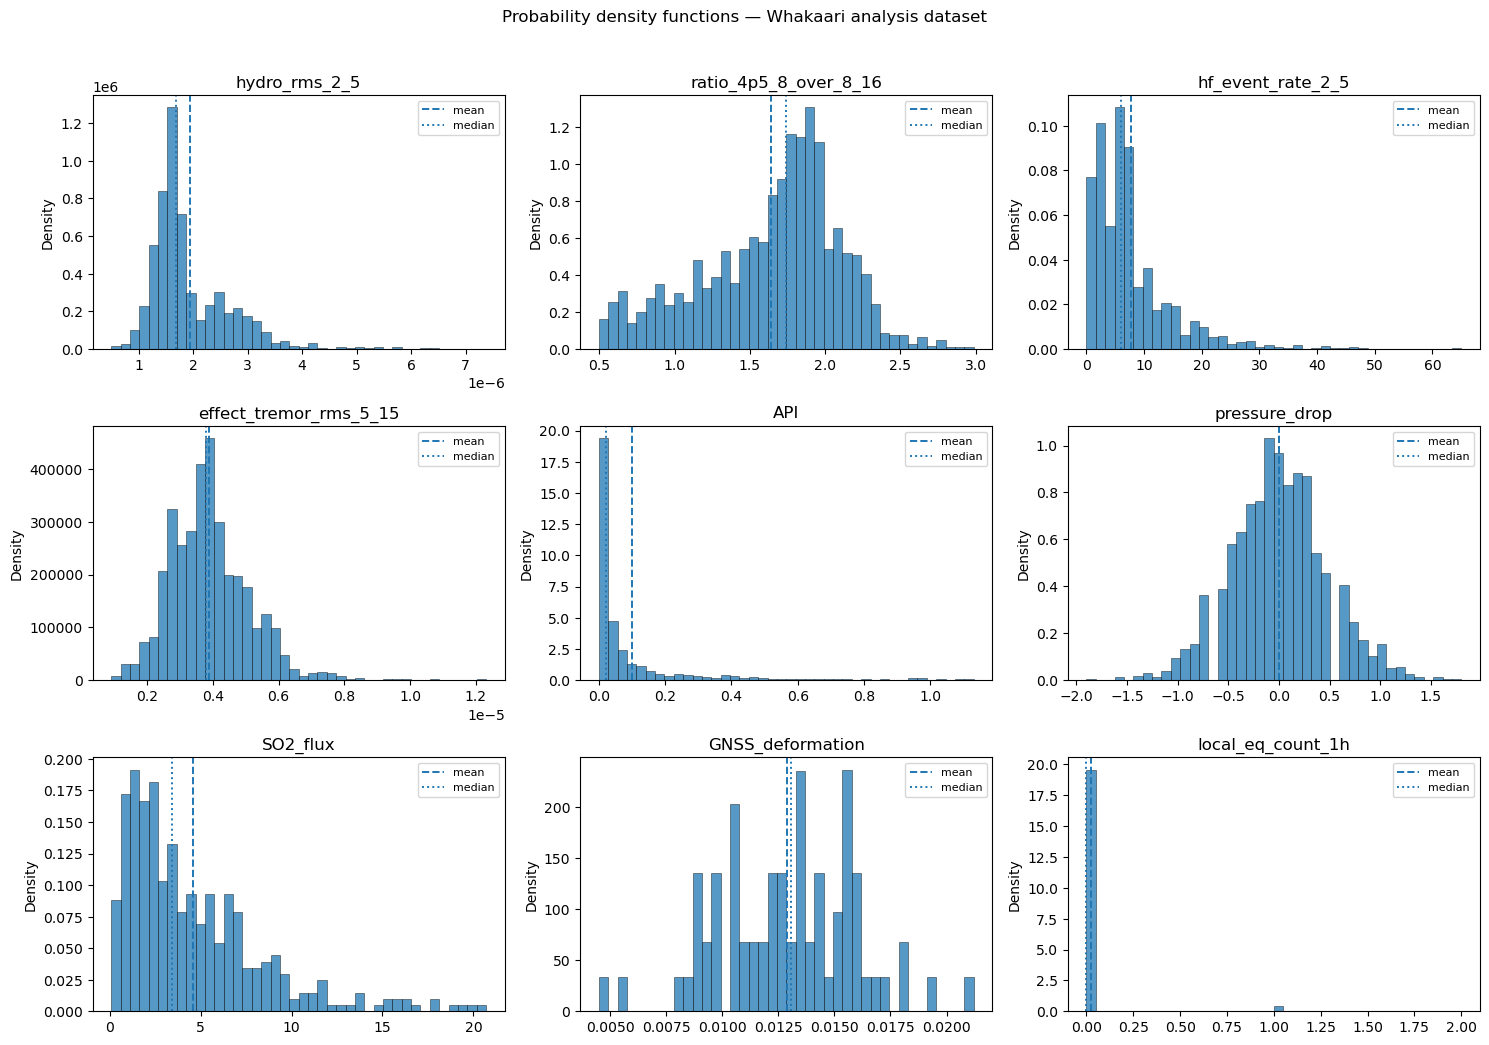

In [8]:
dataset_health_report(whakaari_dataset, "Whakaari analysis dataset")

display(distribution_summary(whakaari_dataset, "Whakaari analysis dataset"))

plot_variable_pdfs(
    whakaari_dataset,
    name="Whakaari analysis dataset",
    cols=WHAKAARI_ALL_COLS,
    bins=40,
)


Whakaari scaled dataset
shape: (1700, 9)
duplicate timestamps: 0
time sorted: True

Missing fraction:
hydro_rms_2_5             0.000000
ratio_4p5_8_over_8_16     0.000000
hf_event_rate_2_5         0.000000
effect_tremor_rms_5_15    0.000000
pressure_drop             0.000000
GNSS_deformation          0.000000
local_eq_count_1h         0.000000
API                       0.000588
SO2_flux                  0.767647
dtype: float64
Whakaari scaled dataset


,count,mean,std,min,median,max,skew,n_unique,missing_fraction
API,1699.0,-6.691397e-17,1.000000,-0.572187,-4.257006e-01,4.580033,2.608092,1699,0.000588
GNSS_deformation,1700.0,-5.325522e-02,0.882524,-2.462609,0.000000e+00,2.333451,-0.088004,71,0.000000
SO2_flux,395.0,1.439074e-16,1.000000,-2.202736,-2.293702e-02,2.426019,0.124702,392,0.767647
effect_tremor_rms_5_15,1700.0,9.579146e-02,1.055492,-2.491231,-1.832624e-16,7.386547,0.934650,1700,0.000000
hf_event_rate_2_5,1700.0,-1.103542e-01,1.009937,-2.435078,0.000000e+00,2.807783,-0.329278,45,0.000000
hydro_rms_2_5,1700.0,6.016415e-01,1.802220,-2.678809,0.000000e+00,12.888375,2.079356,1700,0.000000
local_eq_count_1h,1700.0,-3.343731e-17,1.000000,-0.145795,-1.457949e-01,10.422833,6.890367,3,0.000000
pressure_drop,1700.0,-4.099846e-03,1.060265,-4.271775,0.000000e+00,4.046945,0.081461,56,0.000000
ratio_4p5_8_over_8_16,1700.0,-2.491000e-01,1.159984,-3.105597,0.000000e+00,3.106380,-0.495770,1700,0.000000


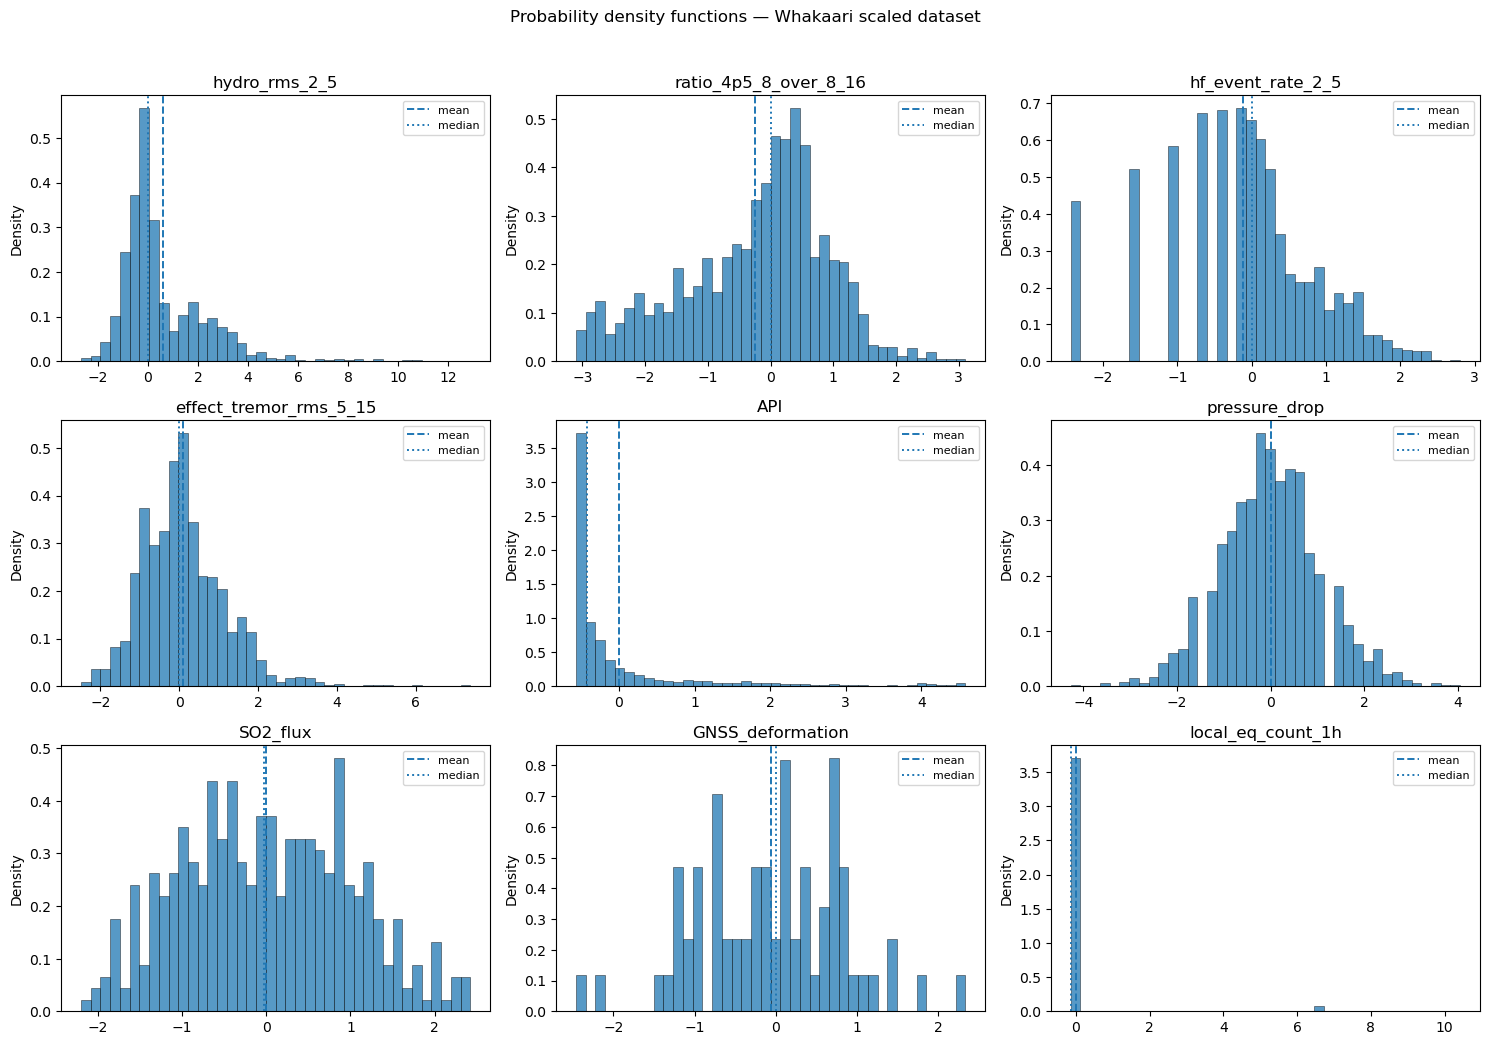

In [9]:
scaled_cols = [c for c in whakaari_dataset_scaled.columns if c in WHAKAARI_ALL_COLS]

dataset_health_report(whakaari_dataset_scaled, "Whakaari scaled dataset")

display(distribution_summary(whakaari_dataset_scaled, "Whakaari scaled dataset"))

plot_variable_pdfs(
    whakaari_dataset_scaled,
    name="Whakaari scaled dataset",
    cols=scaled_cols,
    bins=40,
)

## 6. Final hourly dataset with event marker

The final variables are plotted with the eruption time marked. To assess whether the causal-analysis window and variables are physically meaningful.

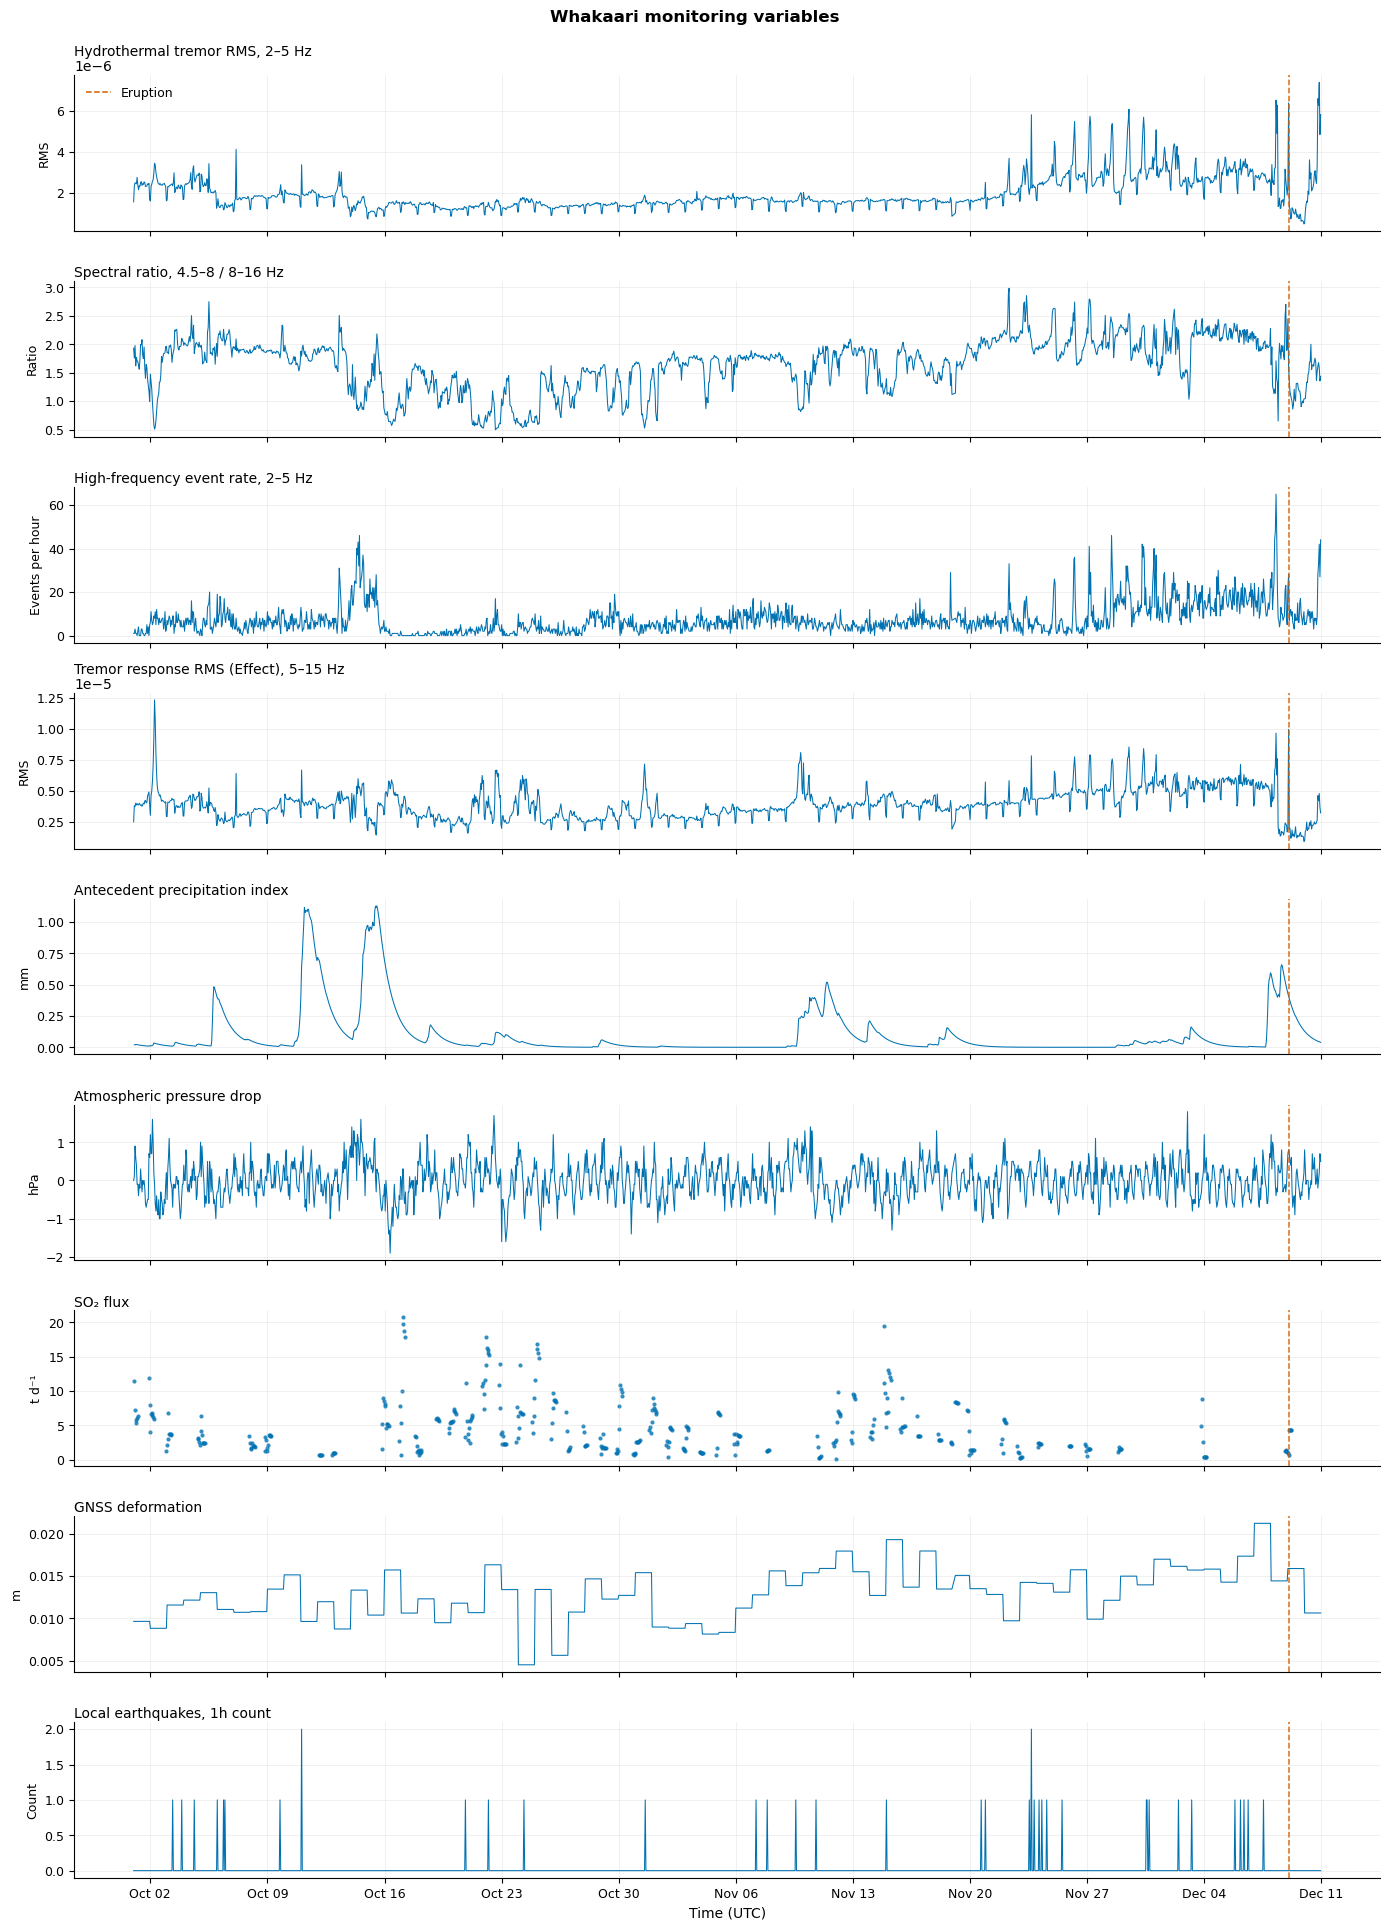

In [ ]:
plot_with_eruption_time(
    "../data/whakaari/whakaari_dataset.csv",
    cols=WHAKAARI_ALL_COLS,
    eruption_time=WHAKAARI_ERUPTION_TIME,
    title="Whakaari monitoring variables",
    tick_interval_days=7,
)

## 7. Geographic Visualization

In [ ]:
whakaari_meta = whakaari_observable_metadata()

whakaari_meta = add_fdsn_station_coordinates(
    metadata=whakaari_meta,
    client=Client("GEONET"),
    network=WHAKAARI_WAVEFORM_CONFIG["network"],
    station_ids=[WHAKAARI_WAVEFORM_CONFIG["station"]],
    location=WHAKAARI_WAVEFORM_CONFIG["location"],
    channel=WHAKAARI_WAVEFORM_CONFIG["channel"],
    starttime=UTCDateTime(WHAKAARI_START),
    endtime=UTCDateTime(WHAKAARI_END),
)

fig, ax = plot_whakaari_observable_locations(whakaari_meta)